In [1]:
import pykep as pk
import heyoka as hy
import numpy as np
import pygmo as pg
from copy import deepcopy

%matplotlib inline

In [2]:
# Tolerances used in the numerical integration
# Lower tolerances are faster but less accurate (required tolerance depends on regime).
tol=1e-10
tol_var = 1e-6

# Instantiate ZOH Taylor integrators for Keplerian dynamics (provided by pykep).
# Contract with leg.zoh: state dimension = 7; first 4 parameters are controls;
# variational dynamics are first-order sensitivities w.r.t. state and controls.
ta_global = pk.ta.get_zoh_kep(tol)
ta_var_global = pk.ta.get_zoh_kep_var(tol_var)

# Non-dimensional units (the ZOH Taylor integrator in pykep expects MU=1).
L = pk.AU
MU = pk.MU_SUN
TIME = np.sqrt(L**3/MU)
V =  L/TIME
ACC = V/TIME
MASS = 1000
F = MASS*ACC

In [3]:
# Starting consitions
pl0 = pk.planet(pk.udpla.jpl_lp("earth"))
epoch0 = pk.epoch(1345., pk.epoch.julian_type.MJD2000)
posvel0 = pl0.eph(epoch0)
# End conditions
pl1 = pk.planet(pk.udpla.jpl_lp("mars"))
epoch1 = pk.epoch(1745., pk.epoch.julian_type.MJD2000)
posvel1 = pl1.eph(epoch1)
# Assemble ballistic arc
tof = (epoch1.mjd2000-epoch0.mjd2000) * pk.DAY2SEC
l = pk.lambert_problem(r0 = posvel0[0], r1 = posvel1[0], tof = tof, mu = pl0.mu_central_body)   
# Produce ballistic arc states
N=10
r0, v0 = posvel0[0], l.v0[0]
tgrid = np.linspace(0, tof, N)
states = pk.propagate_lagrangian_grid([r0, v0], tgrid, pl0.mu_central_body)
# Flatten states and add mass and put all in non dimensional units
states_flattened_nd = []
for state in states:
    states_flattened_nd.extend([r/L for r in state[0]])
    states_flattened_nd.extend([v/V for v in state[1]])
    states_flattened_nd.extend([1.0])
tgrid_nd = tgrid / TIME
# Define ballistic controls
controls_nd = [0.2, 0.0,  1.0, 0.0] * (N-1)
# Construct leg (multiple-shooting)
leg = pk.leg.zoh_ms_py(states_flattened_nd, controls_nd, tgrid_nd, cut = 0.5, tas = [ta_global, ta_var_global])

In [10]:
leg.set_initial_guess(ballistic=False)

In [11]:
leg.compute_defects()

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.47522563839075166,
 -0.3981301958509542,
 -0.016592516688561626,
 -0.1410101036031281,
 1.9331602090411235,
 -0.04769075981713426,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [12]:
fwd, bck, _ = leg.get_state_info(100)

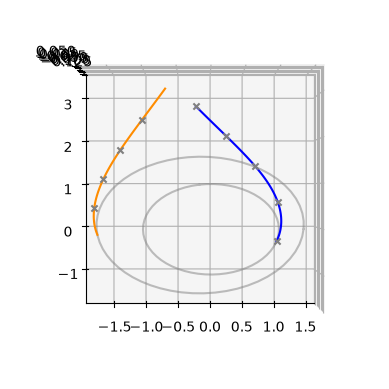

In [13]:
ax = pk.plot.make_3Daxis()
pk.plot.add_planet_orbit(ax, pl0, units=pk.AU, color = 'gray', alpha=0.5)
pk.plot.add_planet_orbit(ax, pl1, units=pk.AU, color = 'gray', alpha=0.5)
for i, segment in enumerate(fwd)    :
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue') 
    #start_state = leg.states[i*7:(i+1)*7]
    #final_state = leg.states[(i+1)*7:(i+2)*7]
    #ax.scatter(start_state[0], start_state[1], start_state[2], c='blue', marker='o')
    #ax.scatter(final_state[0], final_state[1], final_state[2], c='blue', marker='o')
for j, segment in enumerate(bck):
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange') 
    #start_state = leg.states[-7*(j+1): -7*j] if j != 0 else leg.states[-7:]
    #final_state = leg.states[-7*(j+2): -7*(j+1)]
    #ax.scatter(start_state[0], start_state[1], start_state[2], c='darkorange', marker='x')
    #ax.scatter(final_state[0], final_state[1], final_state[2], c='darkorange', marker='x')
for i in range(len(leg.tgrid)-1):
    ax.scatter(leg.states[i*7], leg.states[i*7+1], leg.states[i*7+2], c='gray', marker='x')

ax.view_init(90,-90)